In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset=pd.read_csv("Mall_Customers.csv")

In [3]:
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
x=dataset.iloc[:,[3,4]].values

In [5]:
x

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

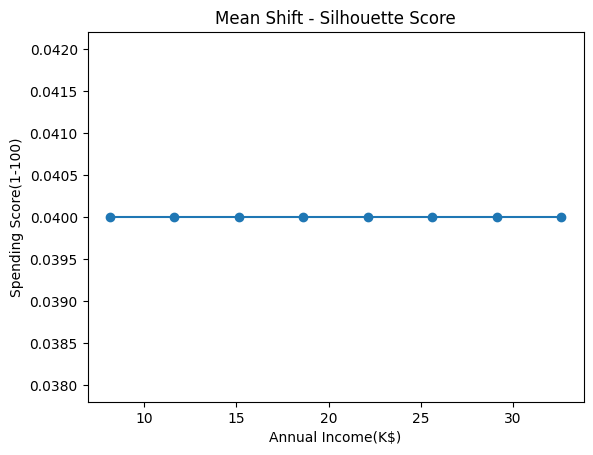

Bandwidth: 8.15 --> Clusters: 196
Bandwidth: 11.64 --> Clusters: 196
Bandwidth: 15.13 --> Clusters: 196
Bandwidth: 18.62 --> Clusters: 196
Bandwidth: 22.12 --> Clusters: 196
Bandwidth: 25.61 --> Clusters: 196
Bandwidth: 29.10 --> Clusters: 196
Bandwidth: 32.59 --> Clusters: 196


In [26]:
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score

silhouette_scores = []
cluster_counts = []

# Estimate bandwidth
bandwidth = estimate_bandwidth(x, quantile=0.2, n_samples=300)

# Try multiple bandwidth values
bandwidth_values = np.linspace(bandwidth*0.3, bandwidth*1.2, 8)

for bw in bandwidth_values:
    ms = MeanShift(
        bandwidth=bw,
        bin_seeding=True
    )
    ms = MeanShift(bandwidth=0.5)  # try smaller values like 0.2, 0.3, 0.5
    labels = ms.fit_predict(x)
    n_clusters = len(set(labels))
    
    cluster_counts.append(n_clusters)
    
    # Fix: Only calculate silhouette if clusters > 1
    if n_clusters > 1:
        score = silhouette_score(x, labels)
    else:
        score = np.nan   # or 0
    
    silhouette_scores.append(score)

# Plot
plt.plot(bandwidth_values, silhouette_scores, marker='o')
plt.title("Mean Shift - Silhouette Score")
plt.xlabel("Annual Income(K$)")
plt.ylabel("Spending Score(1-100)")
plt.show()

# Print cluster counts
for bw, c in zip(bandwidth_values, cluster_counts):
    print(f"Bandwidth: {bw:.2f} --> Clusters: {c}")

In [21]:
y_pred=ms.fit_predict(x)

In [22]:
y_pred

array([195, 194, 193, 192, 191, 190, 189, 188, 187, 185, 186, 184, 182,
       181, 183, 180, 179, 178, 177, 176, 175, 174, 173, 172, 171, 168,
       170, 169, 167, 166, 165, 164, 163, 160, 162, 161, 159, 158, 157,
       156, 155, 154, 152, 151, 153, 150, 148, 149,   3,   3, 147, 146,
       143, 142, 144, 145, 140, 141, 138, 139, 136, 137, 135, 134, 130,
         2, 131, 132,   2, 133, 128, 129, 127, 126, 121, 116, 117, 120,
       118, 124, 119, 115, 125, 123, 114, 122, 112, 113, 110, 111, 108,
       109, 104, 107, 106, 102, 105, 103, 101, 100,  99,  97,  94,  96,
        95,  98,  90,  92,  93,  91,  89,  88,  87,  86,  84,  83,  85,
        82,  80,  78,  79,  81,  77,  76,  75,  74,  71,  70,  72,   1,
        73,   1,  69,  68,  67,  64,  66,  65,  63,  62,  61,  60,  59,
        58,  57,  54,  56,  55,  50,  44,  52,  46,  51,  48,  53,  45,
         0,  47,   0,  49,  43,  42,  41,  40,  39,  38,  37,  36,  33,
        32,  34,  31,  35,  30,  29,  26,  28,  27,  25,  24,  2

In [23]:
from sklearn.metrics import silhouette_score
score=silhouette_score(x,y_pred)

In [24]:
score

0.04

C:\Users\lokes\Anaconda3\envs\aiml\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


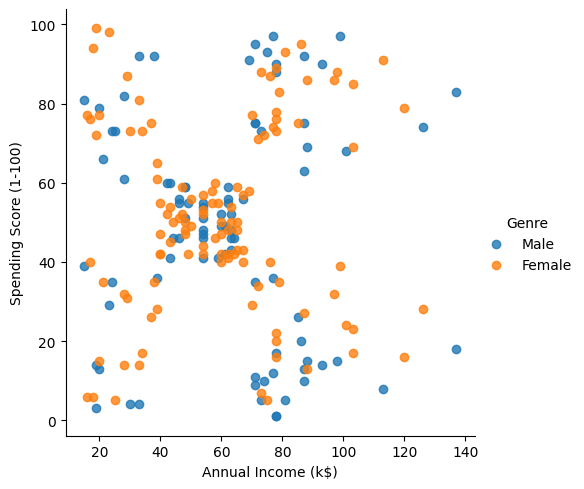

In [25]:
import seaborn as sns
facet = sns.lmplot(
    data = dataset,
       x = dataset.columns[3],
       y = dataset.columns[4],
     hue = dataset.columns[1],
  fit_reg= False,
  legend = True,
legend_out = True)